## **Testing model**


In [ ]:
import torch
import warnings
import numpy as np
import matplotlib.pyplot as plt
from rich import print
from tqdm.rich import tqdm

from torch.utils.data import DataLoader
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                            recall_score, confusion_matrix, roc_curve)

from config import OUT_DIR
from src.Dataset import ChestXRayDataset
from src.Model import InfernoCalibNet

from tqdm import TqdmExperimentalWarning

warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

def test_model():
    torch.cuda.empty_cache()

    test_dt = ChestXRayDataset(OUT_DIR / "test.csv", transform=False)
    test_loader = DataLoader(
        test_dt, batch_size=32, shuffle=False, num_workers=4, pin_memory=True
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = InfernoCalibNet(num_classes=3).to(device)

    model.load_state_dict(
        torch.load(
            OUT_DIR / "InfernoCalibNet_model.pth",
            map_location=device,
            weights_only=True,
        )
    )
    model.eval()

    running_loss = 0.0
    all_preds, all_labels = [], []
    criterion = torch.nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="[blue]Testing", leave=False):
            images, labels = images.to(device, non_blocking=True), labels.to(
                device, non_blocking=True
            )

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(test_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")
    precision = precision_score(
        all_labels, all_preds, average="weighted", zero_division=0
    )
    recall = recall_score(all_labels, all_preds, average="weighted")

    print(
        f"Test Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.4f} | Test F1 Score: {f1:.4f} | Test Precision: {precision:.4f} | Test Recall: {recall:.4f}"
    )
    return all_labels, all_preds

all_labels, all_preds = test_model()


Output()

Test Loss: 0.7329 | Test Accuracy: 0.7116 | Test F1 Score: 0.7108 | Test Precision: 0.7142 | Test Recall: 0.7116

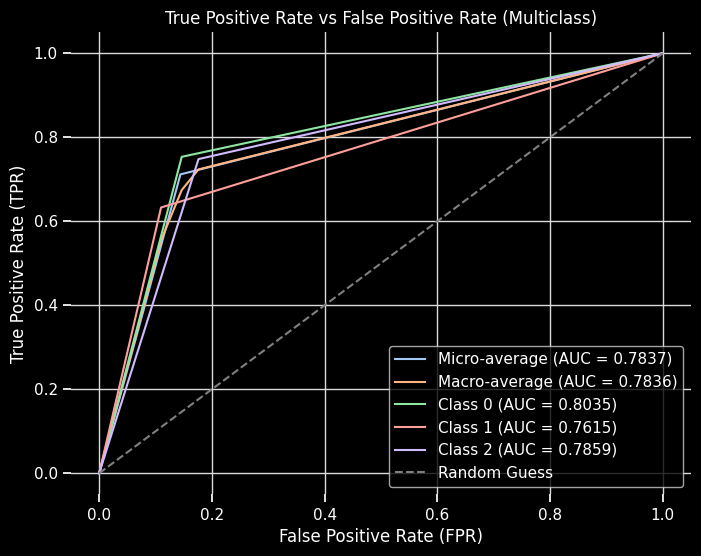

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_tpr_vs_fpr(all_labels, all_preds, num_classes, save_path="roc_curve.svg"):
    sns.set_context('notebook')
    sns.set_palette('pastel', n_colors=5)
    
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    
    if all_preds.ndim == 1:
        # Convert class indices to one-hot encoding
        all_preds = label_binarize(all_preds, classes=np.arange(num_classes))
    
    # Binarize labels for one-vs-rest ROC computation
    all_labels_bin = label_binarize(all_labels, classes=np.arange(num_classes))
    
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_facecolor("#000000")  # Set full figure background color
    ax.set_facecolor("#000000")  # Set plot background color
    plt.grid(color="#dbdbdb")  # Set grid color to match background
    
    # Remove plot borders
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # Micro-average ROC curve (aggregates all classes)
    fpr_micro, tpr_micro, _ = roc_curve(all_labels_bin.ravel(), all_preds.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    sns.lineplot(x=fpr_micro, y=tpr_micro, linestyle="-", label=f"Micro-average (AUC = {auc_micro:.4f})")
    
    # Macro-average ROC curve (averages individual class curves)
    all_fpr = np.unique(np.concatenate([roc_curve(all_labels_bin[:, i], all_preds[:, i])[0] for i in range(num_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_preds[:, i])
        mean_tpr += np.interp(all_fpr, fpr, tpr)
    mean_tpr /= num_classes
    auc_macro = auc(all_fpr, mean_tpr)
    sns.lineplot(x=all_fpr, y=mean_tpr, linestyle="-", label=f"Macro-average (AUC = {auc_macro:.4f})")
    
    # Individual class ROC curves
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_preds[:, i])
        roc_auc = auc(fpr, tpr)
        sns.lineplot(x=fpr, y=tpr, label=f"Class {i} (AUC = {roc_auc:.4f})")
    
    sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--", color="gray", label="Random Guess")
    
    # plt.style.use('dark_background')
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("True Positive Rate vs False Positive Rate (Multiclass)")
    plt.legend()
    plt.savefig(save_path, format='svg')
    plt.show()

# Example usage:
plot_tpr_vs_fpr(all_labels, all_preds, num_classes=3)

## **Highlighting model prediction area**

tensor([[[-2.1179, -2.1179, -2.1179,  ..., -1.9638, -1.9638, -1.9809],
         [-2.1179, -2.1179, -2.1179,  ..., -1.6898, -1.6727, -1.7069],
         [-2.1179, -2.1179, -2.1179,  ..., -1.6727, -1.6555, -1.6898],
         ...,
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]]])


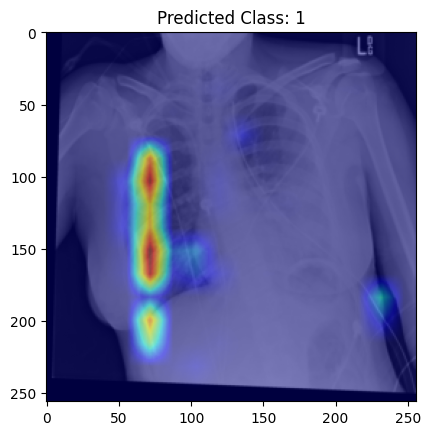

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import preprocess_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from config import OUT_DIR
from src.Dataset import ChestXRayDataset
from src.Model import InfernoCalibNet

def apply_gradcam(model, image, device):
    model.eval()
    
    # Select the last convolutional layer before the classifier
    target_layer = model.base_model[-1]  # The last layer before pooling
    
    cam = GradCAM(model=model, target_layers=[target_layer])
    
    image = image.unsqueeze(0).to(device)
    image_processed = image.clone().detach().requires_grad_(True)
    
    with torch.no_grad():
        output = model(image_processed)
    class_idx = torch.argmax(output, dim=1).item()
    targets = [ClassifierOutputTarget(class_idx)]
    
    grayscale_cam = cam(input_tensor=image_processed, targets=targets)[0]
    
    grayscale_cam = np.maximum(grayscale_cam, 0)
    grayscale_cam = grayscale_cam - grayscale_cam.min()
    grayscale_cam = grayscale_cam / grayscale_cam.max()
    
    return grayscale_cam, class_idx

def plot_gradcam(image, gradcam_map, class_idx):
    fig, ax = plt.subplots()
    ax.imshow(image.cpu().squeeze(), cmap="gray")
    ax.imshow(gradcam_map, cmap="jet", alpha=0.5)
    ax.set_title(f"Predicted Class: {class_idx}")
    plt.show()

def visualize_gradcam():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = InfernoCalibNet(num_classes=3).to(device)
    
    model.load_state_dict(
        torch.load(OUT_DIR / "InfernoCalibNet_model.pth", map_location=device, weights_only=True)
    )
    model.eval()
    
    dataset = ChestXRayDataset(OUT_DIR / "test.csv", transform=False)
    image, _ = dataset[14]  # Load a single image
    print(image)
    
    gradcam_map, class_idx = apply_gradcam(model, image, device)
    plot_gradcam(image, gradcam_map, class_idx)

# Example usage
visualize_gradcam()


## **Print out model summary**

In [10]:
import os
import torch
from torch.utils.tensorboard import SummaryWriter
from torchinfo import summary
from rich import print

from config import OUT_DIR
from src.Model import InfernoCalibNet

# Define model parameters
BATCH_SZ = 32
CHANNELS = 1  # Grayscale images
IMG_SIZE = 256

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InfernoCalibNet(num_classes=3).to(device)

# Print model summary
sumz = summary(
    model, 
    input_size=(BATCH_SZ, CHANNELS, IMG_SIZE, IMG_SIZE), 
    depth=2,  
    col_names=("output_size", "num_params"),  
    row_settings=("var_names", "depth")  
)

print(sumz) 

# Initialize TensorBoard writer
writer = SummaryWriter(log_dir=os.path.join(OUT_DIR, "tensorboard_logs"))

# Create a dummy input tensor
dummy_input = torch.randn(BATCH_SZ, CHANNELS, IMG_SIZE, IMG_SIZE).to(device)

# Add model graph to TensorBoard
writer.add_graph(model, dummy_input)

# Test the model with the dummy input
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    dummy_output = model(dummy_input)

print(f"Dummy Output Shape: {dummy_output.shape}")  # Log output shape for verification

# Close the TensorBoard writer
writer.close()


=========================================================================================================
Layer (type (var_name):depth-idx)                       Output Shape              Param #
=========================================================================================================
InfernoCalibNet (InfernoCalibNet)                       [32, 3]                   --
├─Sequential (base_model): 1-1                          [32, 2048, 16, 16]        --
│    └─Conv2d (0): 2-1                                  [32, 64, 256, 256]        576
│    └─BatchNorm2d (1): 2-2                             [32, 64, 256, 256]        128
│    └─ReLU (2): 2-3                                    [32, 64, 256, 256]        --
│    └─MaxPool2d (3): 2-4                               [32, 64, 128, 128]        --
│    └─Sequential (4): 2-5                              [32, 256, 128, 128]       215,808
│    └─Sequential (5): 2-6                              [32, 512, 64, 64]         1,219,584
│    └─Sequential (6): 2-7                              [32, 1024, 32, 32]        7,098,368
│    └─Sequential (7): 2-8                              [32, 2048, 16, 16]        14,964,736
├─Sequential (classifier): 1-2                          [32, 3]                   --
│    └─Conv2d (0): 2-9                                  [32, 256, 16, 16]         524,544
│    └─ReLU (1): 2-10                                   [32, 256, 16, 16]         --
│    └─Dropout (2): 2-11                                [32, 256, 16, 16]         --
│    └─Conv2d (3): 2-12                                 [32, 128, 16, 16]         295,040
│    └─ReLU (4): 2-13                                   [32, 128, 16, 16]         --
│    └─Dropout (5): 2-14                                [32, 128, 16, 16]         --
│    └─AdaptiveAvgPool2d (6): 2-15                      [32, 128, 1, 1]           --
│    └─Flatten (7): 2-16                                [32, 128]                 --
│    └─Linear (8): 2-17                                 [32, 3]                   387
=========================================================================================================
Total params: 24,319,171
Trainable params: 24,319,171
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 671.50
=========================================================================================================
Input size (MB): 8.39
Forward/backward pass size (MB): 29754.39
Params size (MB): 97.28
Estimated Total Size (MB): 29860.06
=========================================================================================================

Dummy Output Shape: torch.Size([32, 3])